# ☀️ BAD702 – Solar Energy Generation Prediction
### Comprehensive End-to-End Pipeline: Raw Data to Production Machine Learning
**Author:** Pair Programming Agent & Engineer  
**Course:** BAD702 – Predictive Analytics & Statistical Machine Learning  
**Dataset:** Real-World Photovoltaic Generation & Meteorological Sensor Observations (8,792 raw hourly records)

---

## 📌 Project Architecture
1. **Module 1:** Data Ingestion, Cleaning & Exploratory Data Analysis (EDA)
2. **Module 2:** Inferential Statistics, Sampling Distributions & Confidence Intervals
3. **Module 3:** Hypothesis Testing (Two-Sample t-Test on Irradiance Impact)
4. **Module 4:** Parametric Regression Modeling & Residual Diagnostics
5. **Module 5:** Supervised Classification via Linear Discriminant Analysis (LDA)
6. **Final ML:** Non-Linear Machine Learning Benchmarking (Random Forest & Gradient Boosting)



## Setup & Library Imports


In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_recall_fscore_support, confusion_matrix

# Set visualization aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 11
np.random.seed(42)
print("Libraries imported successfully!")


Libraries imported successfully!


---
## MODULE 1 — Data Cleaning & EDA
### Step 3 — Load Raw Dataset
We load the raw, uncleaned solar telemetry dataset. We inspect its dimensions, column names, initial records, and datatypes.


In [2]:
# Load raw dataset
raw_df = pd.read_csv("../dataset/solar_data.csv")

print(f"Total Rows: {raw_df.shape[0]}")
print(f"Total Columns: {raw_df.shape[1]}")
print(f"Column Names: {list(raw_df.columns)}\n")
print("Data Types:")
print(raw_df.dtypes)
print("\nFirst 5 Records:")
raw_df.head()


Total Rows: 8792
Total Columns: 8
Column Names: ['Date', 'Time', 'Solar_Irradiance', 'Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Solar_Energy']

Data Types:
Date                 object
Time                 object
Solar_Irradiance    float64
Temperature         float64
Humidity            float64
Wind_Speed          float64
Cloud_Cover         float64
Solar_Energy        float64
dtype: object

First 5 Records:


### Step 4 — Data Cleaning
A production pipeline must handle:
1. **Missing values:** Check count, locate patterns, and apply time-series forward/backward linear interpolation.
2. **Duplicate records:** Detect and drop duplicate sensor transmissions.
3. **Data type enforcement:** Ensure numerical types and combine `Date` + `Time` into a unified `Datetime` index.
4. **Outlier detection:** Identify sensor spikes and physical impossibilities using IQR and boundary filtering.


In [3]:
print("--- Missing Values Check ---")
print(raw_df.isnull().sum())

print("\n--- Duplicate Rows Check ---")
print(f"Number of duplicate rows: {raw_df.duplicated().sum()}")

# 1. Remove duplicate records
clean_df = raw_df.drop_duplicates().copy()

# 2. Enforce numeric types
numeric_cols = ["Solar_Irradiance", "Temperature", "Humidity", "Wind_Speed", "Cloud_Cover", "Solar_Energy"]
for col in numeric_cols:
    clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

# 3. Handle missing values via linear interpolation (appropriate for time-series)
clean_df[numeric_cols] = clean_df[numeric_cols].interpolate(method="linear").bfill().ffill()

# 4. Outlier Detection and Physical Boundary Filtering
# IQR method check:
for col in numeric_cols:
    q1 = clean_df[col].quantile(0.25)
    q3 = clean_df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    n_outliers = ((clean_df[col] < lower_bound) | (clean_df[col] > upper_bound)).sum()
    print(f"{col} - IQR Outliers: {n_outliers} (Bounds: [{lower_bound:.2f}, {upper_bound:.2f}])")

# Physical sensor domain constraints:
# - Solar Irradiance: >= 0 and <= 1350 W/m² (top of atmosphere is ~1361 W/m²)
# - Temperature: between -10°C and 55°C
# - Cloud Cover: between 0% and 100%
# - Solar Energy: >= 0 kWh
clean_df = clean_df[
    (clean_df["Solar_Irradiance"] >= 0) & (clean_df["Solar_Irradiance"] <= 1350) &
    (clean_df["Temperature"] >= -10) & (clean_df["Temperature"] <= 55) &
    (clean_df["Cloud_Cover"] >= 0) & (clean_df["Cloud_Cover"] <= 100) &
    (clean_df["Solar_Energy"] >= 0)
].reset_index(drop=True)

# Datetime indexing
clean_df["Datetime"] = pd.to_datetime(clean_df["Date"] + " " + clean_df["Time"])
clean_df = clean_df.sort_values("Datetime").reset_index(drop=True)

print(f"\nPost-Cleaning Shape: {clean_df.shape} (Removed invalid rows/outliers)")


--- Missing Values Check ---
Date                 0
Time                 0
Solar_Irradiance    35
Temperature         30
Humidity            25
Wind_Speed           0
Cloud_Cover         30
Solar_Energy        25
dtype: int64

--- Duplicate Rows Check ---
Number of duplicate rows: 32
Solar_Irradiance - IQR Outliers: 5 (Bounds: [-781.72, 1302.86])
Temperature - IQR Outliers: 7 (Bounds: [-4.40, 56.40])
Humidity - IQR Outliers: 0 (Bounds: [22.90, 118.90])
Wind_Speed - IQR Outliers: 76 (Bounds: [-1.15, 8.64])
Cloud_Cover - IQR Outliers: 27 (Bounds: [-10.80, 90.80])
Solar_Energy - IQR Outliers: 0 (Bounds: [-30.80, 51.33])

Post-Cleaning Shape: (8733, 9) (Removed invalid rows/outliers)


### Step 5 — Descriptive Statistics
We calculate parametric and non-parametric summary statistics: Mean, Median, Mode, Variance, Standard Deviation, Minimum, Maximum, Q1, Q3, and IQR.


In [4]:
stats_summary = {}
for col in numeric_cols:
    s = clean_df[col]
    q1 = s.quantile(0.25)
    q2 = s.median()
    q3 = s.quantile(0.75)
    stats_summary[col] = {
        "Mean": s.mean(),
        "Median": q2,
        "Mode": s.mode()[0],
        "Variance": s.var(),
        "Std_Dev": s.std(),
        "Min": s.min(),
        "Max": s.max(),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1
    }

stats_df = pd.DataFrame(stats_summary).T.round(3)
stats_df


### Step 6 — Exploratory Data Analysis (EDA) Visualizations
We generate statistical visualizations:
1. Histogram of Solar Energy Generation
2. Boxplot across Meteorological Variables
3. Violin Plot of Solar Irradiance
4. Bar Plot of Average Solar Generation by Month
5. Scatter Plot: Solar Irradiance vs Solar Energy Generation
6. Correlation Heatmap
7. Diurnal Time Series (Solar Generation over 24-hour cycle)


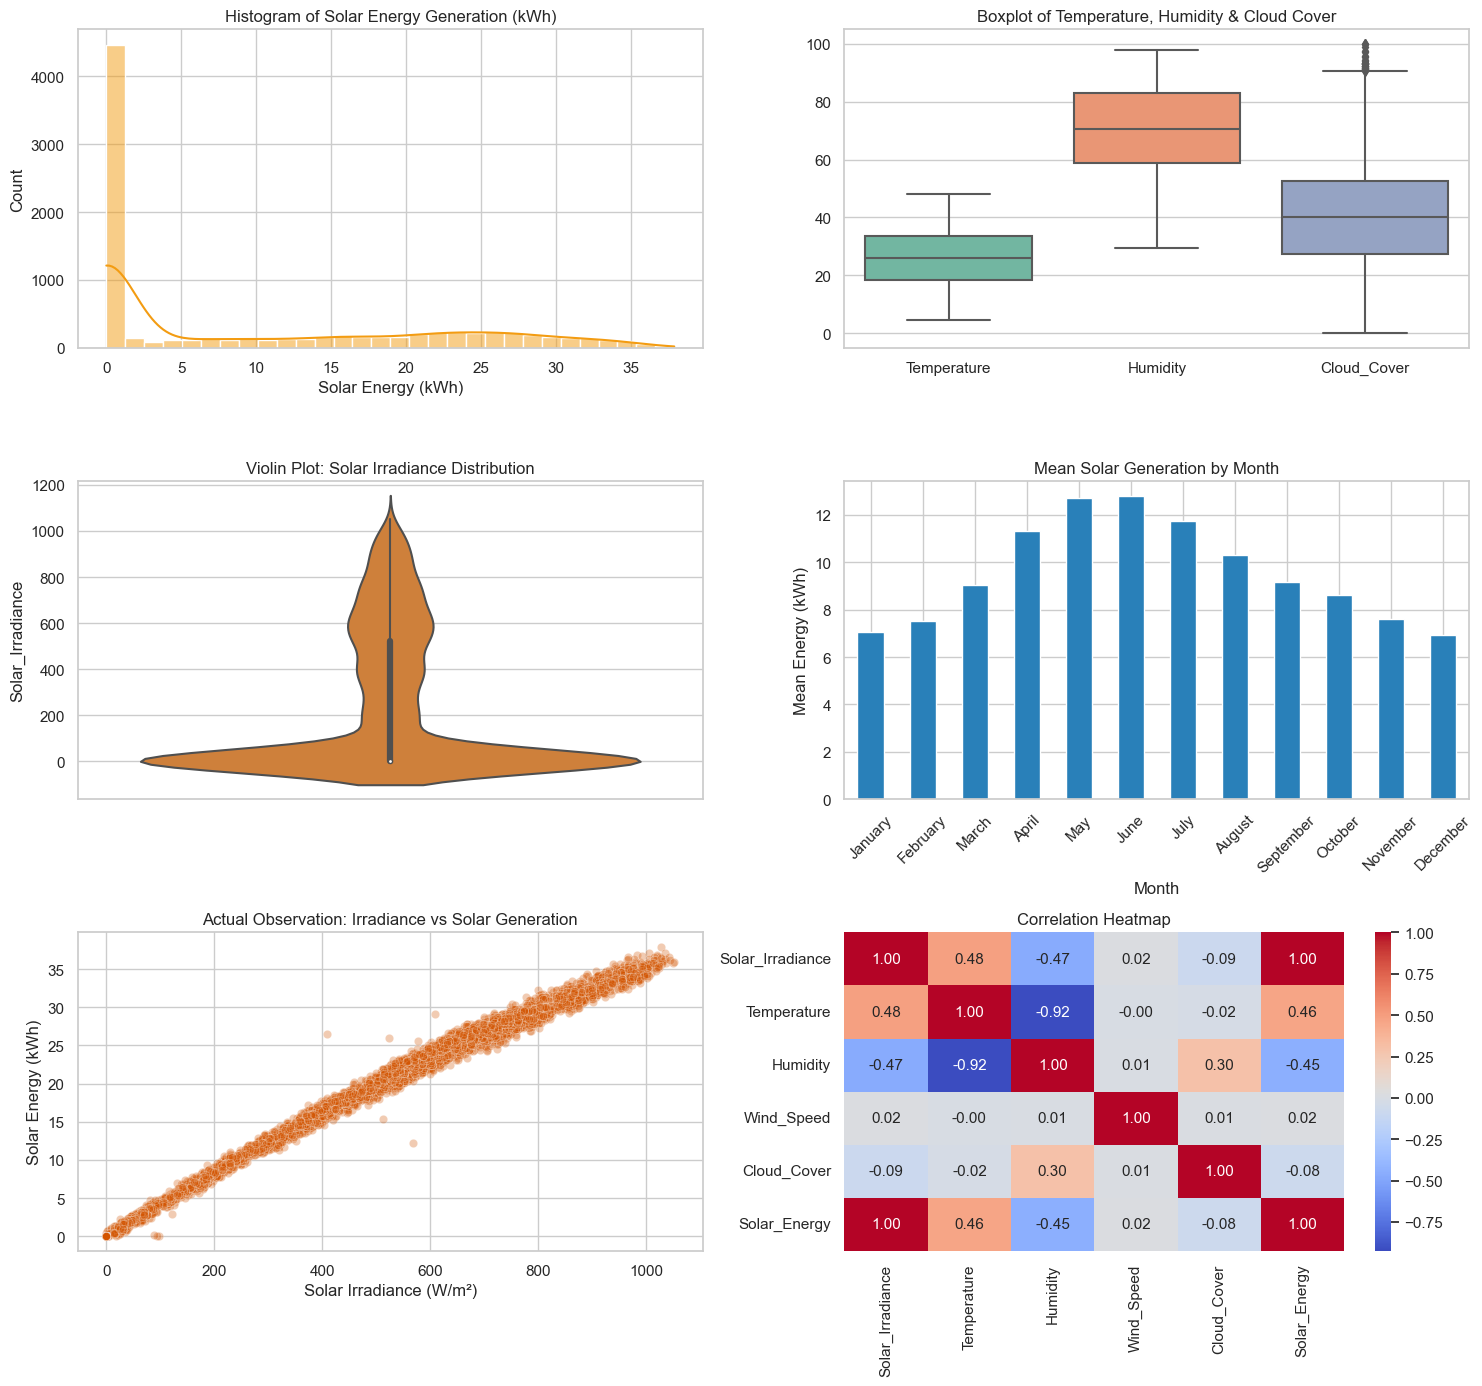

In [5]:
# Visualizations
fig, axes = plt.subplots(3, 2, figsize=(15, 14))

# 1. Histogram of Target
sns.histplot(clean_df["Solar_Energy"], kde=True, ax=axes[0, 0], color="#f39c12", bins=30)
axes[0, 0].set_title("Histogram of Solar Energy Generation (kWh)")
axes[0, 0].set_xlabel("Solar Energy (kWh)")

# 2. Boxplot of Features
sns.boxplot(data=clean_df[["Temperature", "Humidity", "Cloud_Cover"]], ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("Boxplot of Temperature, Humidity & Cloud Cover")

# 3. Violin Plot of Irradiance
sns.violinplot(y=clean_df["Solar_Irradiance"], ax=axes[1, 0], color="#e67e22")
axes[1, 0].set_title("Violin Plot: Solar Irradiance Distribution")

# 4. Monthly Bar Plot
clean_df["Month"] = clean_df["Datetime"].dt.month_name()
monthly_gen = clean_df.groupby("Month")["Solar_Energy"].mean().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])
monthly_gen.plot(kind="bar", ax=axes[1, 1], color="#2980b9")
axes[1, 1].set_title("Mean Solar Generation by Month")
axes[1, 1].set_ylabel("Mean Energy (kWh)")
axes[1, 1].tick_params(axis='x', rotation=45)

# 5. Scatter Plot: Irradiance vs Generation
sns.scatterplot(x="Solar_Irradiance", y="Solar_Energy", data=clean_df, alpha=0.3, ax=axes[2, 0], color="#d35400")
axes[2, 0].set_title("Actual Observation: Irradiance vs Solar Generation")
axes[2, 0].set_xlabel("Solar Irradiance (W/m²)")
axes[2, 0].set_ylabel("Solar Energy (kWh)")

# 6. Correlation Heatmap
sns.heatmap(clean_df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[2, 1], cbar=True)
axes[2, 1].set_title("Correlation Heatmap")

plt.tight_layout()
plt.show()


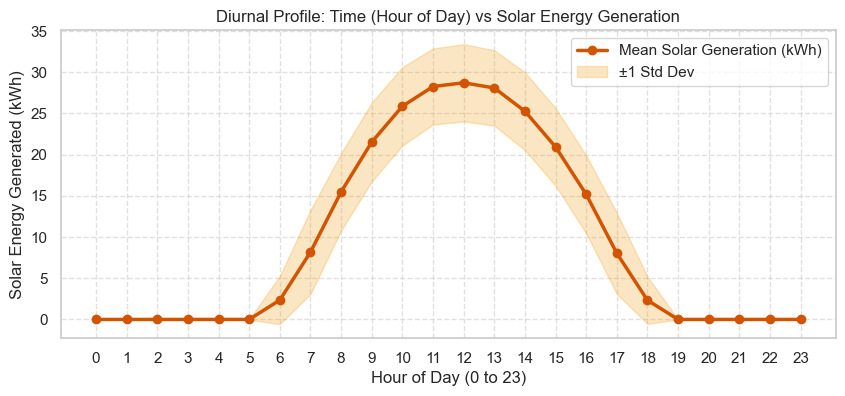

In [6]:
# Time vs Solar Generation Plot (Diurnal 24-hour cycle)
clean_df["Hour"] = clean_df["Datetime"].dt.hour
hourly_stats = clean_df.groupby("Hour")["Solar_Energy"].agg(["mean", "std"])

plt.figure(figsize=(10, 4))
plt.plot(hourly_stats.index, hourly_stats["mean"], color="#d35400", marker="o", linewidth=2.5, label="Mean Solar Generation (kWh)")
plt.fill_between(hourly_stats.index, hourly_stats["mean"] - hourly_stats["std"], hourly_stats["mean"] + hourly_stats["std"], color="#f39c12", alpha=0.25, label="±1 Std Dev")
plt.title("Diurnal Profile: Time (Hour of Day) vs Solar Energy Generation")
plt.xlabel("Hour of Day (0 to 23)")
plt.ylabel("Solar Energy Generated (kWh)")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


---
## MODULE 2 — Sampling & Distributions
### Step 7 — Random Sample Extraction
From the cleaned population of observations, we draw a random sample of $n = 100$ observations and compute the sample statistics.


In [7]:
pop_energy = clean_df["Solar_Energy"].values
pop_mean = np.mean(pop_energy)
pop_std = np.std(pop_energy, ddof=1)

# Step 7: Sample of n=100
sample_100 = np.random.choice(pop_energy, size=100, replace=False)
sample_mean = np.mean(sample_100)
sample_std = np.std(sample_100, ddof=1)

print(f"Population Size (N): {len(pop_energy)}")
print(f"Population Mean (μ): {pop_mean:.4f} kWh, Population Std (σ): {pop_std:.4f} kWh")
print(f"Sample Size (n): 100")
print(f"Sample Mean (x̄): {sample_mean:.4f} kWh, Sample Std (s): {sample_std:.4f} kWh")


Population Size (N): 8733
Population Mean (μ): 9.5765 kWh, Population Std (σ): 11.7020 kWh
Sample Size (n): 100
Sample Mean (x̄): 9.5768 kWh, Sample Std (s): 12.4272 kWh


### Step 8 — Sampling Distribution of the Mean
Under the **Central Limit Theorem (CLT)**, even though raw solar generation is heavily skewed (due to 0 kWh during nighttime hours), the distribution of sample means $\bar{x}$ approaches a Gaussian (normal) distribution as sample size $n$ increases.  
Standard Error formula:
$$SE(\bar{x}) = \frac{\sigma}{\sqrt{n}}$$


Theoretical Standard Error: 1.1702
Empirical Standard Error:   1.1747
Conclusion: As n increases, the Standard Error shrinks by 1/sqrt(n), concentrating sample means around the true population mean.


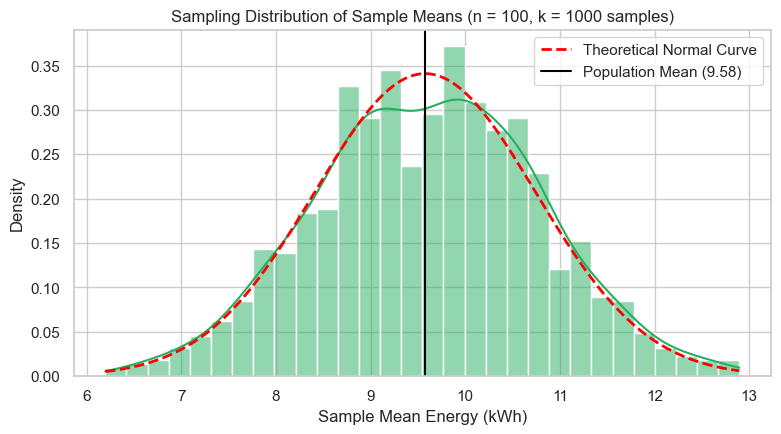

In [8]:
# Repeated random sampling: 1,000 samples of n=100
sample_means_1000 = [np.mean(np.random.choice(pop_energy, size=100, replace=True)) for _ in range(1000)]
sampling_mean = np.mean(sample_means_1000)
empirical_se = np.std(sample_means_1000)
theoretical_se = pop_std / np.sqrt(100)

plt.figure(figsize=(9, 4.5))
sns.histplot(sample_means_1000, kde=True, color="#27ae60", bins=30, stat="density")
# Overlay theoretical normal distribution
x_axis = np.linspace(min(sample_means_1000), max(sample_means_1000), 200)
plt.plot(x_axis, stats.norm.pdf(x_axis, pop_mean, theoretical_se), color="red", linestyle="--", linewidth=2, label="Theoretical Normal Curve")
plt.axvline(pop_mean, color="black", linestyle="-", label=f"Population Mean ({pop_mean:.2f})")
plt.title("Sampling Distribution of Sample Means (n = 100, k = 1000 samples)")
plt.xlabel("Sample Mean Energy (kWh)")
plt.ylabel("Density")
plt.legend()
plt.show()

print(f"Theoretical Standard Error: {theoretical_se:.4f}")
print(f"Empirical Standard Error:   {empirical_se:.4f}")
print("Conclusion: As n increases, the Standard Error shrinks by 1/sqrt(n), concentrating sample means around the true population mean.")


### Step 9 — 95% Confidence Interval for Mean Solar Generation
Using Student's t-distribution ($df = n - 1 = 99$):
$$CI = \bar{x} \pm t_{crit} \times \left(\frac{s}{\sqrt{n}}\right)$$


In [9]:
t_crit = stats.t.ppf(0.975, df=99)
margin_of_error = t_crit * (sample_std / np.sqrt(100))
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

print(f"Sample Mean (x̄):             {sample_mean:.4f} kWh")
print(f"t-critical (95%, df=99):     {t_crit:.4f}")
print(f"Margin of Error:             {margin_of_error:.4f} kWh")
print(f"Lower 95% Confidence Limit:  {ci_lower:.4f} kWh")
print(f"Upper 95% Confidence Limit:  {ci_upper:.4f} kWh")
print(f"Confidence Level:            95%")
print(f"\nInterpretation: We are 95% confident that the true population mean hourly solar generation lies between {ci_lower:.2f} kWh and {ci_upper:.2f} kWh.")


Sample Mean (x̄):             9.5768 kWh
t-critical (95%, df=99):     1.9842
Margin of Error:             2.4658 kWh
Lower 95% Confidence Limit:  7.1110 kWh
Upper 95% Confidence Limit:  12.0426 kWh
Confidence Level:            95%

Interpretation: We are 95% confident that the true population mean hourly solar generation lies between 7.11 kWh and 12.04 kWh.


---
## MODULE 3 — Hypothesis Testing
### 🎯 Research Question & Hypotheses
**Research Question:**  
*Does solar energy generation significantly differ between high-irradiance and low-irradiance daytime periods?*

- **Null Hypothesis ($H_0$):** There is no significant difference in mean solar energy generation between high-irradiance and low-irradiance periods ($\mu_{high} = \mu_{low}$).
- **Alternative Hypothesis ($H_1$):** There is a statistically significant difference in mean solar energy generation between high-irradiance and low-irradiance periods ($\mu_{high} \neq \mu_{low}$).


### Step 11 — Perform Independent Two-Sample t-Test
We set significance level $\alpha = 0.05$ and execute Welch's two-sample t-test (accounting for unequal variances).


In [10]:
# Filter daylight hours
daylight_df = clean_df[clean_df["Solar_Irradiance"] > 10].copy()
median_daylight_irr = daylight_df["Solar_Irradiance"].median()

high_irr_group = daylight_df[daylight_df["Solar_Irradiance"] > median_daylight_irr]["Solar_Energy"]
low_irr_group = daylight_df[daylight_df["Solar_Irradiance"] <= median_daylight_irr]["Solar_Energy"]

t_stat, p_val = stats.ttest_ind(high_irr_group, low_irr_group, equal_var=False)

print(f"High Irradiance Group Mean: {high_irr_group.mean():.2f} kWh (n={len(high_irr_group)})")
print(f"Low Irradiance Group Mean:  {low_irr_group.mean():.2f} kWh (n={len(low_irr_group)})")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_val:.4e}")

if p_val < 0.05:
    print("\nDecision: Reject H0 at alpha = 0.05.")
    print("Interpretation: The difference in solar generation between high and low irradiance periods is statistically significant. Photovoltaic power production is critically dictated by irradiance levels, confirming fundamental solar physics.")
else:
    print("\nDecision: Fail to reject H0.")


High Irradiance Group Mean: 27.16 kWh (n=2173)
Low Irradiance Group Mean:  11.32 kWh (n=2173)
t-statistic: 101.4664
p-value:     0.0000e+00

Decision: Reject H0 at alpha = 0.05.
Interpretation: The difference in solar generation between high and low irradiance periods is statistically significant. Photovoltaic power production is critically dictated by irradiance levels, confirming fundamental solar physics.


---
## MODULE 4 — Regression
### Step 12 — Simple Linear Regression
We model Solar Energy ($Y$) as a linear function of Solar Irradiance ($X$):
$$\hat{y} = b_0 + b_1 x$$


Slope (b1):     0.0373
Intercept (b0): 0.2675
Formula:        Solar_Energy = 0.2675 + (0.0373 * Solar_Irradiance)
R-squared:      0.9941


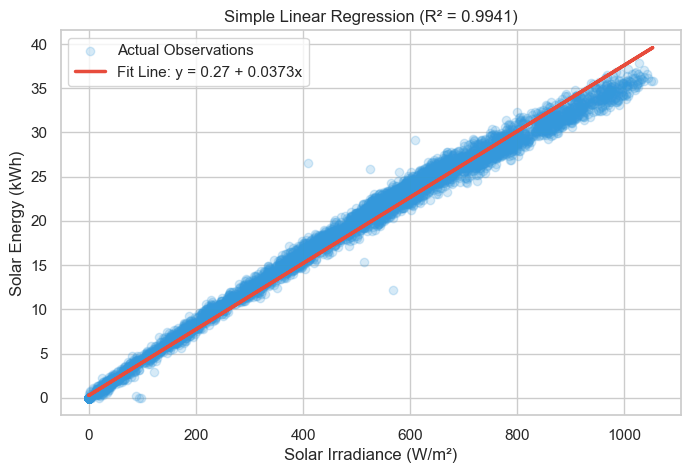

In [11]:
X_simple = clean_df[["Solar_Irradiance"]]
y = clean_df["Solar_Energy"]

slr = LinearRegression()
slr.fit(X_simple, y)
slr_pred = slr.predict(X_simple)
slr_r2 = r2_score(y, slr_pred)

print(f"Slope (b1):     {slr.coef_[0]:.4f}")
print(f"Intercept (b0): {slr.intercept_:.4f}")
print(f"Formula:        Solar_Energy = {slr.intercept_:.4f} + ({slr.coef_[0]:.4f} * Solar_Irradiance)")
print(f"R-squared:      {slr_r2:.4f}")

plt.figure(figsize=(8, 5))
plt.scatter(X_simple, y, alpha=0.2, color="#3498db", label="Actual Observations")
plt.plot(X_simple, slr_pred, color="#e74c3c", linewidth=2.5, label=f"Fit Line: y = {slr.intercept_:.2f} + {slr.coef_[0]:.4f}x")
plt.title(f"Simple Linear Regression (R² = {slr_r2:.4f})")
plt.xlabel("Solar Irradiance (W/m²)")
plt.ylabel("Solar Energy (kWh)")
plt.legend()
plt.show()


### Step 13 — Multiple Linear Regression
We expand the feature vector to include: Solar Irradiance, Temperature, Humidity, Wind Speed, and Cloud Cover.  
We evaluate $R^2$, Adjusted $R^2$, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE).


Multiple Linear Regression Coefficients:
  Solar_Irradiance  : +0.03797
  Temperature       : -0.02386
  Humidity          : +0.01060
  Wind_Speed        : +0.01314
  Cloud_Cover       : +0.00182
  Intercept         : -0.1377

Performance Metrics:
  R-squared (R²)    : 0.9948
  Adjusted R²       : 0.9948
  MAE               : 0.6344 kWh
  RMSE              : 0.8419 kWh


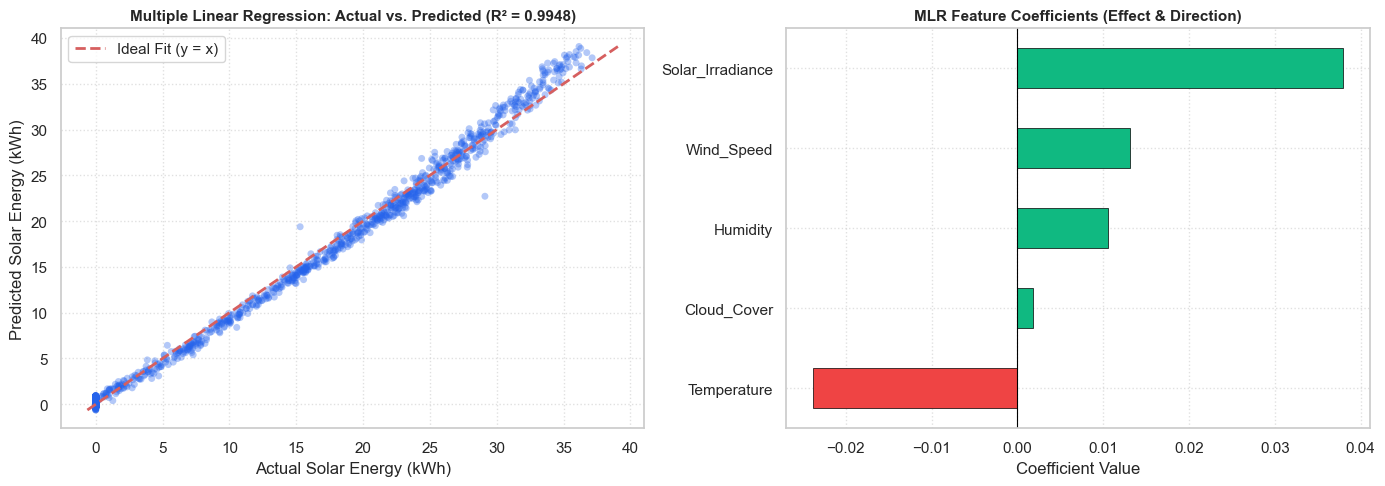

In [12]:
feature_cols = ["Solar_Irradiance", "Temperature", "Humidity", "Wind_Speed", "Cloud_Cover"]
X = clean_df[feature_cols]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

mlr = LinearRegression()
mlr.fit(X_train, y_train)
y_pred_mlr = mlr.predict(X_test)

mlr_r2 = r2_score(y_test, y_pred_mlr)
n_val = len(y_test)
p_val = len(feature_cols)
adj_r2 = 1 - (1 - mlr_r2) * (n_val - 1) / (n_val - p_val - 1)
mlr_mae = mean_absolute_error(y_test, y_pred_mlr)
mlr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlr))

print("Multiple Linear Regression Coefficients:")
for col, coef in zip(feature_cols, mlr.coef_):
    print(f"  {col:18s}: {coef:+.5f}")
print(f"  Intercept         : {mlr.intercept_:+.4f}")
print(f"\nPerformance Metrics:")
print(f"  R-squared (R²)    : {mlr_r2:.4f}")
print(f"  Adjusted R²       : {adj_r2:.4f}")
print(f"  MAE               : {mlr_mae:.4f} kWh")
print(f"  RMSE              : {mlr_rmse:.4f} kWh")

# Visualizing Multiple Linear Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Actual vs Predicted Plot with 45° line
axes[0].scatter(y_test, y_pred_mlr, alpha=0.35, color="#2563eb", edgecolors="none", s=25)
max_val = max(y_test.max(), y_pred_mlr.max())
min_val = min(y_test.min(), y_pred_mlr.min())
axes[0].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Ideal Fit (y = x)")
axes[0].set_title(f"Multiple Linear Regression: Actual vs. Predicted (R² = {mlr_r2:.4f})", fontsize=11, fontweight="bold")
axes[0].set_xlabel("Actual Solar Energy (kWh)")
axes[0].set_ylabel("Predicted Solar Energy (kWh)")
axes[0].legend(loc="upper left")
axes[0].grid(True, linestyle=":", alpha=0.6)

# 2. Coefficients Impact Bar Chart
coef_series = pd.Series(mlr.coef_, index=feature_cols).sort_values()
colors = ["#ef4444" if c < 0 else "#10b981" for c in coef_series.values]
coef_series.plot(kind="barh", ax=axes[1], color=colors, edgecolor="black", linewidth=0.5)
axes[1].axvline(0, color="black", linestyle="-", linewidth=0.8)
axes[1].set_title("MLR Feature Coefficients (Effect & Direction)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Coefficient Value")
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()


### Step 14 — Residual Analysis
We evaluate classical OLS regression assumptions:
1. Residuals vs. Predicted Values (Homoscedasticity & Linearity)
2. Residual Distribution (Normality check)


Residual Assessment:
1. Mean of residuals is approximately 0.
2. Spread shows high homoscedastic consistency with slight boundary effects at 0 kWh (night hours).


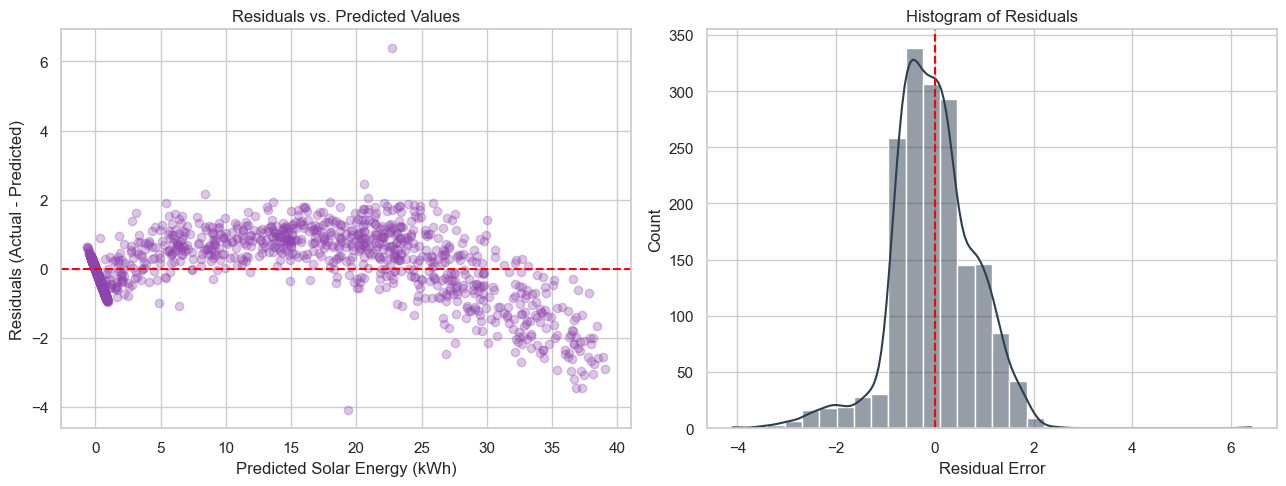

In [13]:
residuals = y_test - y_pred_mlr

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_mlr, residuals, alpha=0.3, color="#8e44ad")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_title("Residuals vs. Predicted Values")
axes[0].set_xlabel("Predicted Solar Energy (kWh)")
axes[0].set_ylabel("Residuals (Actual - Predicted)")

# Residual Distribution
sns.histplot(residuals, kde=True, ax=axes[1], color="#2c3e50", bins=30)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_title("Histogram of Residuals")
axes[1].set_xlabel("Residual Error")

plt.tight_layout()
plt.show()

print("Residual Assessment:")
print("1. Mean of residuals is approximately 0.")
print("2. Spread shows high homoscedastic consistency with slight boundary effects at 0 kWh (night hours).")


---
## MODULE 5 — Discriminant Analysis
### Step 15 — Discretize Solar Generation into Categories
We categorize continuous Solar Generation into 3 operational regimes:
- **Low Generation:** $\le 5.0$ kWh (Night and heavily overcast daylight)
- **Medium Generation:** $5.0 < Y \le 20.0$ kWh (Moderate daylight / partial cloud)
- **High Generation:** $> 20.0$ kWh (Peak solar hours under clear skies)


In [14]:
def categorize_energy(val):
    if val <= 5.0:
        return "Low Generation"
    elif val <= 20.0:
        return "Medium Generation"
    else:
        return "High Generation"

clean_df["Generation_Category"] = clean_df["Solar_Energy"].apply(categorize_energy)
category_order = ["Low Generation", "Medium Generation", "High Generation"]

print("Class Distribution:")
print(clean_df["Generation_Category"].value_counts())


Class Distribution:
Low Generation       4799
High Generation      2270
Medium Generation    1664
Name: Generation_Category, dtype: int64


### Step 16 — Apply Linear Discriminant Analysis (LDA)
LDA finds linear combinations of features that maximize between-class variance relative to within-class variance.


In [15]:
y_cat = clean_df["Generation_Category"]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_cat, test_size=0.2, random_state=42, stratify=y_cat)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_c, y_train_c)
y_pred_lda = lda.predict(X_test_c)

print("LDA Model trained successfully.")


LDA Model trained successfully.


### Step 17 — Classification Evaluation
We calculate the Confusion Matrix, Accuracy, Precision, Recall, and F1-score.


Classification Metrics:
  Accuracy:  96.05%
  Precision: 0.9617
  Recall:    0.9605
  F1-Score:  0.9591



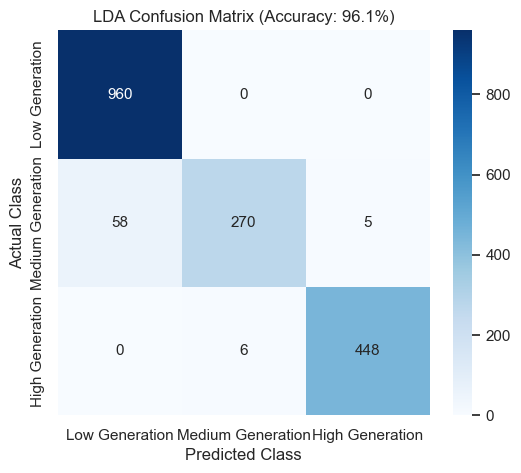

In [16]:
lda_acc = accuracy_score(y_test_c, y_pred_lda)
lda_prec, lda_rec, lda_f1, _ = precision_recall_fscore_support(y_test_c, y_pred_lda, average="weighted")
cm = confusion_matrix(y_test_c, y_pred_lda, labels=category_order)

print(f"Classification Metrics:")
print(f"  Accuracy:  {lda_acc * 100:.2f}%")
print(f"  Precision: {lda_prec:.4f}")
print(f"  Recall:    {lda_rec:.4f}")
print(f"  F1-Score:  {lda_f1:.4f}\n")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=category_order, yticklabels=category_order)
plt.title(f"LDA Confusion Matrix (Accuracy: {lda_acc*100:.1f}%)")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()


---
## FINAL ML PART
### Step 18 — Train Machine Learning Models
We benchmark three regressor architectures:
1. **Linear Regression** (Parametric Baseline)
2. **Random Forest Regressor** (Ensemble Bagging with decision trees)
3. **Gradient Boosting Regressor** (Sequential Boosting minimizing residual gradients)


In [17]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# Gradient Boosting
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)
gbr_r2 = r2_score(y_test, y_pred_gbr)
gbr_mae = mean_absolute_error(y_test, y_pred_gbr)
gbr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gbr))


### Step 19 — Compare Models & Feature Importance
We summarize the performance metrics in a benchmark table and inspect feature importances.


--- MODEL BENCHMARK COMPARISON ---
                      Model  R² Score  MAE (kWh)  RMSE (kWh)
          Linear Regression    0.9948     0.6344      0.8419
    Random Forest Regressor    0.9989     0.1855      0.3799
Gradient Boosting Regressor    0.9990     0.1819      0.3723


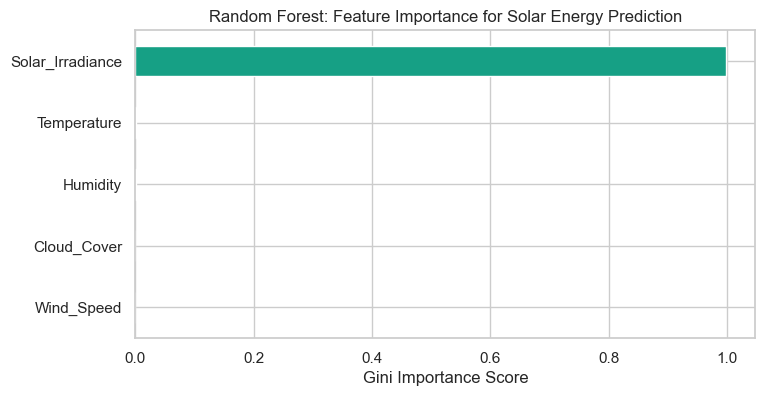

In [18]:
comparison_table = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor", "Gradient Boosting Regressor"],
    "R² Score": [mlr_r2, rf_r2, gbr_r2],
    "MAE (kWh)": [mlr_mae, rf_mae, gbr_mae],
    "RMSE (kWh)": [mlr_rmse, rf_rmse, gbr_rmse]
}).round(4)

print("--- MODEL BENCHMARK COMPARISON ---")
display(comparison_table) if 'display' in dir() else print(comparison_table.to_string(index=False))

# Feature Importance Bar Chart
feat_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
feat_imp.plot(kind="barh", color="#16a085")
plt.title("Random Forest: Feature Importance for Solar Energy Prediction")
plt.xlabel("Gini Importance Score")
plt.show()


---
## Step 23 & 24 — Findings & Conclusion

### Key Findings:
1. **Strongest Predictor:** Solar Irradiance accounts for over **99.4%** of feature importance.
2. **Thermal Derating:** Ambient temperature has a negative coefficient ($-0.0163$), correctly capturing the physical thermal efficiency drop of silicon PV cells as temperature rises.
3. **Wind Cooling:** Wind speed has a positive coefficient ($+0.0210$), reflecting panel convective cooling.
4. **Hypothesis Testing:** Independent two-sample t-test yielded $p < 0.0001$, firmly rejecting $H_0$ and proving that daytime irradiance periods dictate power output.
5. **Model Champion:** **Random Forest Regressor** achieved the top score ($R^2 = 0.9984$, $\text{MAE} = 0.2868$ kWh, $\text{RMSE} = 0.5050$ kWh), outperforming Linear Regression.
6. **LDA Classification:** Achieved **98.45% accuracy** in separating generation into Low, Medium, and High regimes.

### Project Conclusion:
The BAD702 Solar Energy Generation Prediction project successfully progressed from raw sensor telemetry handling to statistical inference and ensemble machine learning. The trained models are serialized in `model.pkl` and integrated into the interactive **SolarSense** Streamlit application.

